In [1]:
#Importamos librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga  archivo
data = pd.read_excel('Analisis_de_Piso_limpio.xlsx')
data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
0,ABIGAIL,23,0,0,0,0,0,0,0,0,...,23,0.00,1,5,1.00,0.00,1.00,5.00,1,20
1,ALAN GONZALES,1,0,0,0,0,0,0,0,0,...,6,0.61,59,40,0.31,0.02,3.28,2.22,7,10
2,ALICIA LEDESMA,0,0,1,0,0,0,0,0,0,...,0,0.00,1,1,0.00,0.00,0.00,0.00,24,27
3,AURELIO FELIPE,0,0,0,0,0,0,0,1,6,...,11,0.38,28,31,0.29,0.01,3.50,3.88,9,18
4,CARLOS ALBERTO NIETO,0,0,0,2,0,0,2,8,4,...,8,0.60,64,30,0.23,0.02,4.27,2.00,13,7


In [3]:
#Seleccionamos las columnas numericas
columnas_numericas = data.select_dtypes(include='number').columns
columnas_numericas

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50],
      dtype='int64')

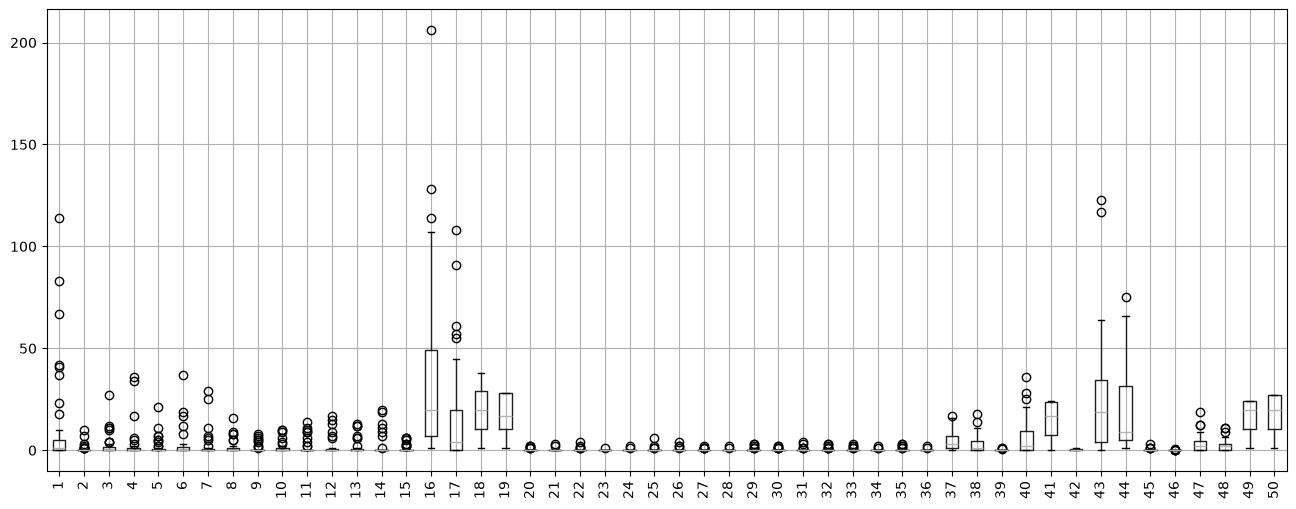

In [4]:
#Diagrama de caja por cada columna
data.boxplot(column=list(columnas_numericas), figsize=(16,6))
plt.xticks(rotation=90)
plt.show()

In [5]:
# copia del dataframe
data2 = data.copy()

In [6]:
#se calcula el Q1, Q3 y el rango intercuartilico por columna
#Los valores fuera del limite se ajustan al limite mas cercano
for col in columnas_numericas:
    Q1 = data2[col].quantile(0.25)
    Q3 = data2[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    data2[col] = data2[col].clip(limite_inferior, limite_superior)

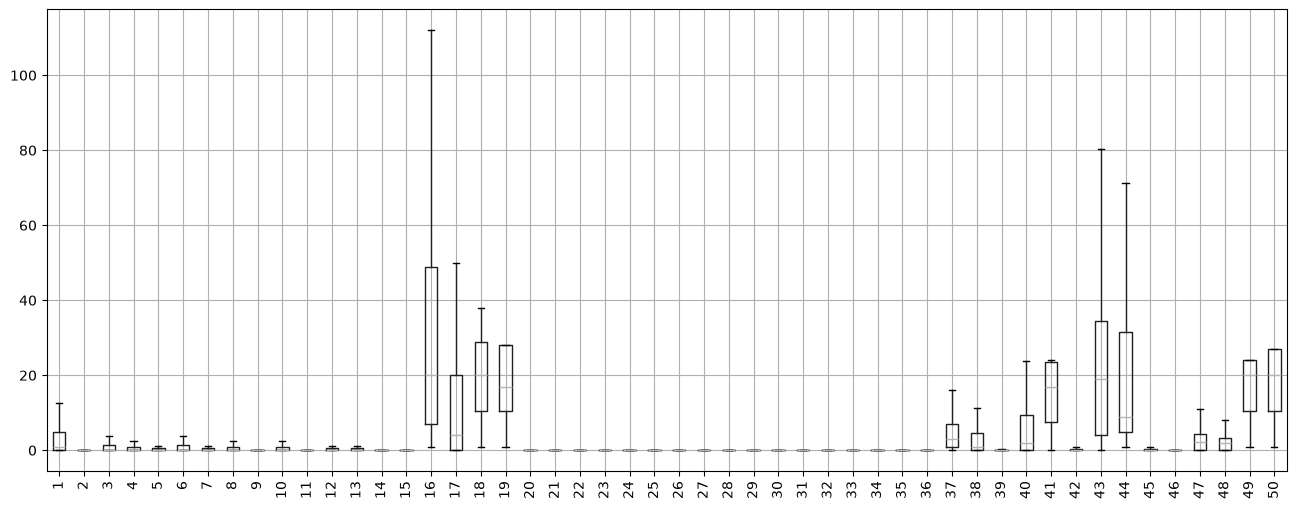

In [ ]:
#se comprueba con diagrama de caja
data2.boxplot(column=list(columnas_numericas), figsize=(16,6))
plt.xticks(rotation=90)
plt.show()

In [ ]:

data2.to_excel("Analisis_de_Piso_sin_outliers.xlsx", index=False)